In [3]:
# IMPORT REQUIRED LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
import warnings

warnings.filterwarnings("ignore")

# NLP Libraries
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Machine Learning Libraries
from sklearn.model_selection import ( train_test_split, cross_val_score, RandomizedSearchCV)

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.pipeline import Pipeline

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import StackingClassifier

from xgboost import XGBClassifier

# Save Model
import pickle

In [4]:
# DOWNLOAD NLTK STOPWORDS
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sahil\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
df = pd.read_csv("spam.csv",encoding='latin-1')

In [6]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [7]:
# Keep only useful columns
df = df[['v1', 'v2']]

In [8]:
# Rename the columns 
df.columns = ['label', 'message']

In [9]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
# Basic Data Inspection 

In [14]:
print("Dataset Shape\n", df.shape)

Dataset Shape
 (5572, 2)


In [15]:
print("Dataset Info\n", df.info(()))

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 541.4 KB
Dataset Info
 None


In [18]:
print("missing values\n", df.isnull().sum())

missing values
 label      0
message    0
dtype: int64


In [20]:
print("Duplicate\n",df.duplicated().sum())

Duplicate
 403


In [21]:
# REMOVE DUPLICATES

df.drop_duplicates(inplace=True)

print("dataset Shape after Removing Duplicates:", df.shape)

dataset Shape after Removing Duplicates: (5169, 2)


In [22]:
# ENCODE TARGET VARIABLE
# ham  = 0
# spam = 1
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [23]:
#Exploratory Data Analysis (EDA) 

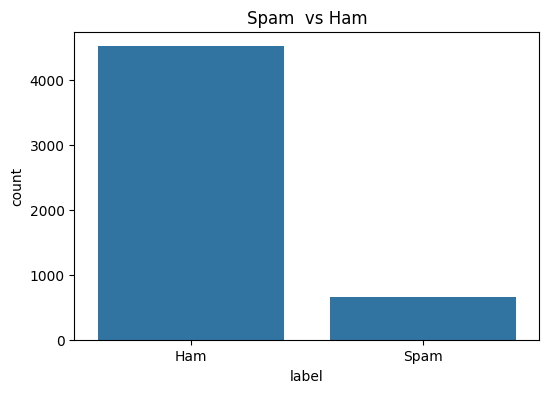

In [25]:
# CLASS DISTRIBUTION

plt.figure(figsize=(6,4))
sns.countplot(x=df['label'])
plt.title("Spam  vs Ham")
plt.xticks([0,1], ['Ham', 'Spam'])
plt.show()

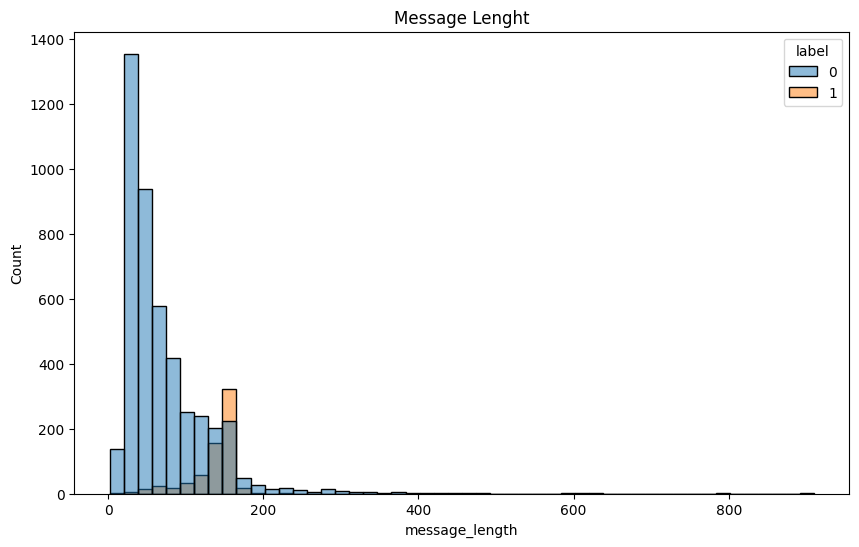

In [27]:
# MESSAGE LENGTH ANALYSIS
df['message_length'] = df['message'].apply(len)
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x='message_length',
    hue='label',
    bins=50
)
plt.title("Message Lenght")
plt.show()

In [28]:
#Average Message Length
print(df.groupby('label')['message_length'].mean())

label
0     70.459256
1    137.891271
Name: message_length, dtype: float64


In [30]:
# TEXT CLEANING FUNCTION
ps = PorterStemmer()

def clean_text(text):

    #convert to lowercase
    text = text.lower()

    #remove special charatects
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    #Tokenization
    words = text.split()

     # Remove stopwords + stemming
    words = [
        ps.stem(word)
        for word in words
        if word not in stopwords.words('english')
    ]

    return " ".join(words)

In [31]:
# APPLY TEXT CLEANING

df['clean_message'] = df['message'].apply(clean_text)

df.head()

,label,message,message_length,clean_message
0,0,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entri wkli comp win fa cup final tkt st m...
3,0,U dun say so early hor... U c already then say...,49,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,nah think goe usf live around though


In [32]:
# FEATURE EXTRACTION USING TF-IDF

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

In [33]:
# DEFINE FEATURES & TARGET
X = df['clean_message']
y = df['label']

In [34]:
# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [50]:
#Build Advanced Ensemble Learning Model
# DEFINE BASE MODELS

# ============================================
# DEFINE BASE MODELS
# ============================================

base_models = [
    ( 'lr', LogisticRegression( class_weight='balanced', C=1, max_iter=1000)),

    ('svm', LinearSVC( class_weight='balanced' )),

    ( 'nb', MultinomialNB()),

    ('xgb', XGBClassifier( eval_metric='logloss', learning_rate=0.1, max_depth=5, n_estimators=200, subsample=0.8, colsample_bytree=0.8 )
    )]

In [51]:
# META MODEL

meta_model = LogisticRegression()

In [52]:
# STACKING CLASSIFIER
stack_model = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=5, n_jobs=-1)

In [53]:
# CREATE PIPELINE
pipeline = Pipeline([('tfidf', tfidf), ('model', stack_model)])

In [54]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [57]:
# PREDICTIONS
y_pred = pipeline.predict(X_test)

In [58]:
# CLASSIFICATION REPORT
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       903
           1       0.98      0.92      0.95       131

    accuracy                           0.99      1034
   macro avg       0.99      0.96      0.97      1034
weighted avg       0.99      0.99      0.99      1034



In [59]:
# PERFORMANCE METRICS

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9874274661508704
Precision: 0.9836065573770492
Recall: 0.916030534351145
F1 Score: 0.9486166007905138


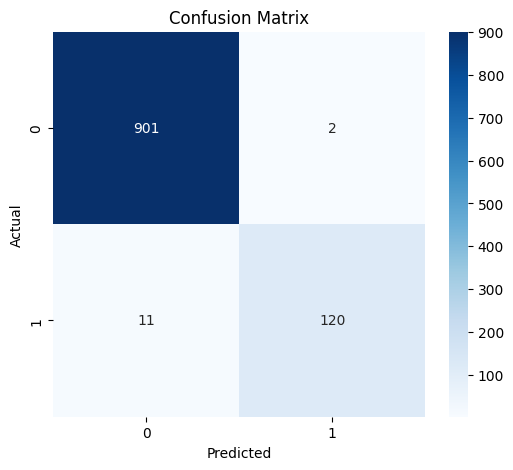

In [61]:
# CONFUSION MATRIX
cm = confusion_matrix(
    y_test,y_pred
)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [62]:
# CROSS VALIDATION
scores = cross_val_score(pipeline, X, y, cv=5, scoring='f1')

print("Cross Validation F1 Scores:", scores)
print('\nAverage F1 Score:', scores.mean())

Cross Validation F1 Scores: [0.96062992 0.93650794 0.93975904 0.92741935 0.92607004]

Average F1 Score: 0.9380772575323146


In [63]:
# HYPERPARAMETER TUNING
params = {
 'tfidf__max_features': [5000, 10000],
 'model__xgb__max_depth': [3,5,7],
 'model__xgb__learning_rate': [0.01, 0.1],
 'model__xgb__n_estimators': [100,200]
}

search = RandomizedSearchCV(
    pipeline, params, n_iter=10, cv=5, scoring='f1', n_jobs=1, random_state=42
)

search.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... n_jobs=-1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__xgb__learning_rate': [0.01, 0.1], 'model__xgb__max_depth': [3, 5, ...], 'model__xgb__n_estimators': [100, 200], 'tfidf__max_features': [5000, 10000]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies t

In [64]:
# BEST PARAMETERS
print(search.best_params_)

{'tfidf__max_features': 5000, 'model__xgb__n_estimators': 100, 'model__xgb__max_depth': 7, 'model__xgb__learning_rate': 0.01}


In [65]:
# BEST MODEL
best_model = search.best_estimator_

In [66]:
# FINAL MODEL EVALUATION
final_pred = best_model.predict(X_test)

print(classification_report(y_test, final_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       903
           1       0.98      0.92      0.95       131

    accuracy                           0.99      1034
   macro avg       0.99      0.96      0.97      1034
weighted avg       0.99      0.99      0.99      1034



In [67]:
# SAVE MODEL

pickle.dump( best_model, open('best_spam_model.pkl','wb'))

print("Model Saved Successfully")

Model Saved Successfully


In [75]:
# CUSTOM EMAIL TEST
sample_email = [ 'Hi Sahil,Your internship meeting is scheduled for tomorrow at 10 AM.Please join using the Zoom link shared earlier']

prediction = best_model.predict(sample_email)
if prediction[0] == 1:
    print("Spam Email")
else:
    print("Ham Email")

Ham Email
